In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Tokenization.ipynb', 'Coursera HJR3YTP71MW4_copy.pdf', 'Screenshot 2026-02-11 101002.png', 'plantvillage', 'TG ICET - 2026 Syllabus_copy.pdf', 'Telangana_DV_List2_copy.pdf', 'Level1_Task2.zip', 'Level2_Task1.zip', 'Level2_Task2.zip', 'Level1_Task1.zip', 'github id or emails.gsheet', 'AI_SKIN_PROJECT']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/AI_SKIN_PROJECT"))

['SKIN_PROJECT_CLEANED2 copy']


In [ ]:
!pwd

/content


In [ ]:
!ls /content/drive

MyDrive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive

MyDrive


In [ ]:
!ls /content/drive/MyDrive

 AI_SKIN_PROJECT		   Level2_Task2.zip
'Colab Notebooks'		   plantvillage
'Coursera HJR3YTP71MW4_copy.pdf'  'Screenshot 2026-02-11 101002.png'
'github id or emails.gsheet'	   Telangana_DV_List2_copy.pdf
 Level1_Task1.zip		  'TG ICET - 2026 Syllabus_copy.pdf'
 Level1_Task2.zip		   Tokenization.ipynb
 Level2_Task1.zip


In [ ]:
!ls /content/drive/MyDrive/AI_SKIN_PROJECT

'SKIN_PROJECT_CLEANED2 copy'


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/AI_SKIN_PROJECT/SKIN_PROJECT_CLEANED2 copy"

print(os.listdir(dataset_path))

['create_test_dataset.py', 'val', 'train', 'test']


In [ ]:
import os

train_path = "/content/drive/MyDrive/AI_SKIN_PROJECT/SKIN_PROJECT_CLEANED2 copy/train"

print(os.listdir(train_path))

['class3_Eczema', 'class4_Rosacea', 'class5_dark_spots', 'class1_acne', 'class2_wrinkles', 'class0_normal']


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/AI_SKIN_PROJECT/SKIN_PROJECT_CLEANED2 copy/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/AI_SKIN_PROJECT/SKIN_PROJECT_CLEANED2 copy/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 7923 files belonging to 6 classes.
Found 944 files belonging to 6 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

print("Dataset optimization completed!")

Dataset optimization completed!


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Load the pre-trained EfficientNetB0 model
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = False

# Build the classification model
model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(6, activation="softmax")
])

print("EfficientNet-B0 model created successfully!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNet-B0 model created successfully!


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [ ]:
%whos

Variable          Type                Data/Info
-----------------------------------------------
AUTOTUNE          int                 -1
BATCH_SIZE        int                 32
EarlyStopping     type                <class 'keras.src.callbac<...>_stopping.EarlyStopping'>
EfficientNetB0    function            <function EfficientNetB0 at 0x7a6d85719120>
IMG_SIZE          tuple               n=2
ModelCheckpoint   type                <class 'keras.src.callbac<...>ckpoint.ModelCheckpoint'>
base_model        Functional          <Functional name=efficientnetb0, built=True>
checkpoint        ModelCheckpoint     <keras.src.callbacks.mode<...>object at 0x7a6d72ceebd0>
dataset_path      str                 /content/drive/MyDrive/AI<...>KIN_PROJECT_CLEANED2 copy
drive             module              <module 'google.colab.dri<...>s/google/colab/drive.py'>
early_stop        EarlyStopping       <keras.src.callbacks.earl<...>object at 0x7a6d72ceeed0>
layers            module              <module 'kera

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications.efficientnet import preprocess_input

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Input Layer
inputs = Input(shape=(224, 224, 3))

# Augmentation
x = data_augmentation(inputs)

# EfficientNet preprocessing
x = preprocess_input(x)

# Base Model
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_tensor=x
)

# Freeze the base model
base_model.trainable = False

# Classification Head
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(6, activation="softmax")(x)

# Final Model
model = Model(inputs, outputs)

print("New model created successfully!")

New model created successfully!


In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ sequential_1[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_3[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_4[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1558s 6s/step - accuracy: 0.7628 - loss: 0.6439 - val_accuracy: 0.7648 - val_loss: 0.6896
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 44s 179ms/step - accuracy: 0.8344 - loss: 0.4478 - val_accuracy: 0.7500 - val_loss: 0.6745
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 82s 181ms/step - accuracy: 0.8531 - loss: 0.3952 - val_accuracy: 0.7797 - val_loss: 0.6869
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 46s 186ms/step - accuracy: 0.8716 - loss: 0.3584 - val_accuracy: 0.7977 - val_loss: 0.6541
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 81s 184ms/step - accuracy: 0.8816 - loss: 0.3279 - val_accuracy: 0.7881 - val_loss: 0.6493
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 46s 185ms/step - accuracy: 0.8848 - loss: 0.3164 - val_accuracy: 0.7818 - val_loss: 0.7019
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 48s 194ms/step - accuracy: 0.8897 - loss: 0.2951 - val_accuracy: 0.8146 - val_loss: 0.6486
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 47s 189ms/step - accuracy: 0.8973 - loss: 0.

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Fine-tuning enabled!")

Fine-tuning enabled!


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning!")

Model recompiled for fine-tuning!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# New callbacks for fine-tuning
early_stop_ft = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

checkpoint_ft = ModelCheckpoint(
    "best_finetuned_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history_finetune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=[early_stop_ft, checkpoint_ft]
)

Epoch 1/5
248/248 ━━━━━━━━━━━━━━━━━━━━ 67s 210ms/step - accuracy: 0.7697 - loss: 0.7093 - val_accuracy: 0.7680 - val_loss: 0.8508
Epoch 2/5
248/248 ━━━━━━━━━━━━━━━━━━━━ 76s 194ms/step - accuracy: 0.8051 - loss: 0.5615 - val_accuracy: 0.7722 - val_loss: 0.8148
Epoch 3/5
248/248 ━━━━━━━━━━━━━━━━━━━━ 83s 196ms/step - accuracy: 0.8292 - loss: 0.4871 - val_accuracy: 0.7786 - val_loss: 0.7860
Epoch 4/5
248/248 ━━━━━━━━━━━━━━━━━━━━ 50s 200ms/step - accuracy: 0.8503 - loss: 0.4356 - val_accuracy: 0.7828 - val_loss: 0.7511
Epoch 5/5
248/248 ━━━━━━━━━━━━━━━━━━━━ 50s 203ms/step - accuracy: 0.8493 - loss: 0.4196 - val_accuracy: 0.7892 - val_loss: 0.7381


In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/AI_SKIN_PROJECT/SKIN_PROJECT_CLEANED2 copy/test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Found 804 files belonging to 6 classes.
26/26 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step - accuracy: 0.9229 - loss: 0.2060
Test Accuracy: 92.29%
Test Loss: 0.2060


In [ ]:
model.save("skin_disease_model.keras")

In [ ]:
model.save("skin_disease_model.keras")

print("Model saved successfully!")

Model saved successfully!


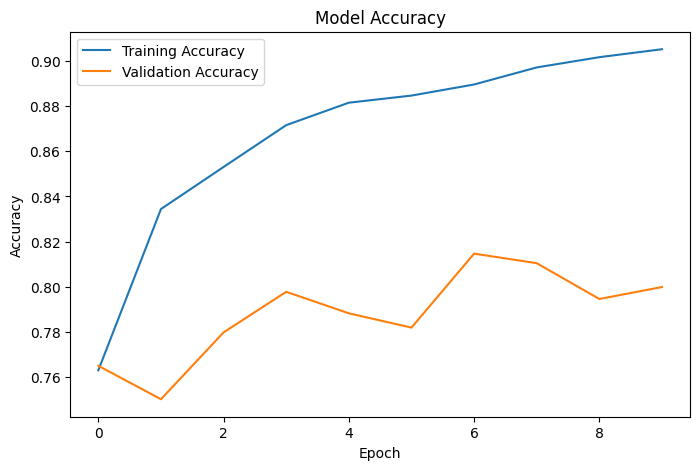

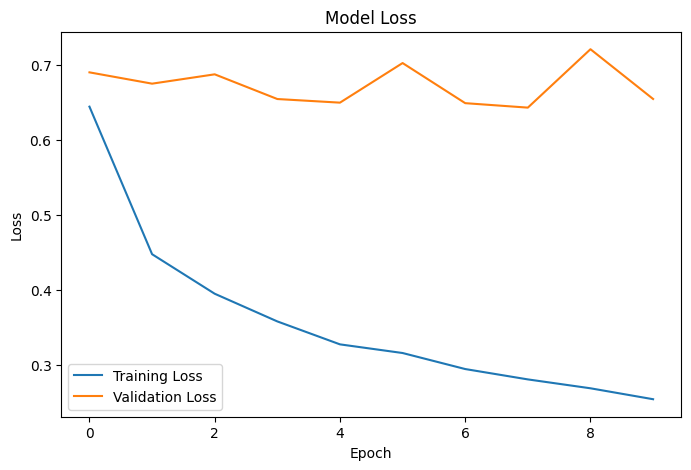

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.save("skin_disease_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download("skin_disease_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>